In [ ]:
'''
To run this shole jupyter notebook as a python script follow this:

(1) activate conda environemt
(2) go to where this notebook is located in your computer
(3) use `python` to enter python with in your shell/terminal
(4) follow the above syntax


from json import load

filename = 'viz_CCA_surf2netmat.ipynb'
with open(filename) as fp:
    nb = load(fp)

for cell in nb['cells']:
    if cell['cell_type'] == 'code':
        source = ''.join(line for line in cell['source'] if not line.startswith('%'))
        exec(source, globals(), locals())


'''

In [2]:
# PCA first
import numpy as np
# import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
# import utils


In [ ]:
local_root= "" # "/Users/snaranjo/Desktop/neurotranslate/mount_point"
data_root_path = f"{local_root}/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch" #/Users/snaranjo/Desktop/neurotranslate/mount_point
dataset_choice = "ABCD"
write_fpath=f"{data_root_path}/NeuroTranslate/surf2netmat/batch/kSiTLN_recon_normICAdemeanfishzMAT.print"
hemi_cond="1L"

#ico2
train_ico2_same = np.load(f'{data_root_path}/NeuroTranslate/surf2netmat/utils/train_ico2_corr_samesubj_channels.npy')
train_ico2_other = np.load(f'{data_root_path}/NeuroTranslate/surf2netmat/utils/train_ico2_corr_othersubj_channels.npy')
# write_to_file(train_ico2_same.shape, train_ico2_other.shape, filepath=write_fpath)

# ico5
train_ico5_same = np.load(f'{data_root_path}/NeuroTranslate/surf2netmat/utils/train_ico5_corr_samesubj_channels.npy')
train_ico5_other = np.load(f'{data_root_path}/NeuroTranslate/surf2netmat/utils/train_ico5_corr_othersubj_channels.npy')
# write_to_file(train_ico5_same.shape, train_ico5_other.shape, filepath=write_fpath)


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 24))
axes=axes.flatten()
# Flatten arrays if needed
train_ico2_same = train_ico2_same.flatten()
train_ico2_other = train_ico2_other.flatten()
train_ico5_same = train_ico5_same.flatten()
train_ico5_other = train_ico5_other.flatten()

# write_to_file(train_ico2_same.shape, train_ico2_other.shape, train_ico5_same.shape, train_ico5_other.shape, filepath=write_fpath)

list_tr_ico2_same = [np.mean(train_ico2_same), np.std(train_ico2_same)]
list_tr_ico2_other = [np.mean(train_ico2_other), np.std(train_ico2_other)]
list_tr_ico5_same = [np.mean(train_ico5_same), np.std(train_ico5_same)]
list_tr_ico5_other = [np.mean(train_ico5_other), np.std(train_ico5_other)]

# write_to_file(f"Mean(std): \nTrain_ico2same:{list_tr_ico2_same[0]:.3f}({list_tr_ico2_same[1]:.3f}) Train_ico2other:{list_tr_ico2_other[0]:.3f}({list_tr_ico2_other[1]:.3f}) \nTrain_ico5same:{list_tr_ico5_same[0]:.3f}({list_tr_ico5_same[1]:.3f}) Train_ico5other:{list_tr_ico5_other[0]:.3f}({list_tr_ico5_other[1]:.3f})", filepath=write_fpath)

# Build long-form DataFrame
df = pd.DataFrame({ # its values per row and col==1 and its group and is different based on concat
    "RHO values": np.concatenate([train_ico2_same, train_ico2_other, train_ico5_same, train_ico5_other]),
    "": ["tr_ico2same"] * len(train_ico2_same) + ["tr_ico2other"] * len(train_ico2_other) + ["tr_ico5same"] * len(train_ico5_same) + ["tr_ico5other"] * len(train_ico5_other)
})
sns.violinplot(data=df, x="", y="RHO values", inner="point", ax=axes[0])

axes[0].set_title("Violin Plot of Rho by Group $ico2ii$")
axes[0].set_ylabel("Rho Values")
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)

# '''Below is for plotting pred i pred j'''
# train_ico2_same = same_pred_train_rho_chnl.flatten()
# train_ico2_other = same_pred_train_rho_chnl_org.flatten()
# train_ico5_same = same_pred_test_rho_chnl.flatten()
# train_ico5_other = same_pred_test_rho_chnl_org.flatten()

# list_tr_ico2_same = [np.mean(train_ico2_same), np.std(train_ico2_same)]
# list_tr_ico2_other = [np.mean(train_ico2_other), np.std(train_ico2_other)]
# list_tr_ico5_same = [np.mean(train_ico5_same), np.std(train_ico5_same)]
# list_tr_ico5_other = [np.mean(train_ico5_other), np.std(train_ico5_other)]

# print(f"Mean(std): \nTrain_dmean:{list_tr_ico2_same[0]:.3f}({list_tr_ico2_same[1]:.3f}) Train_Orig:{list_tr_ico2_other[1]:.3f}({list_tr_ico2_other[0]:.3f}) \nTest_dmean:{list_tr_ico5_same[0]:.3f}({list_tr_ico5_same[1]:.3f}) Test_Orig:{list_tr_ico5_other[0]:.3f}({list_tr_ico5_other[1]:.3f})")

# # Build long-form DataFrame
# df = pd.DataFrame({ # its values per row and col==1 and its group and is different based on concat
#     "RHO values": np.concatenate([train_ico2_same, train_ico2_other, train_ico5_same, train_ico5_other]),
#     "": ["tr_dmean"] * len(train_ico2_same) + ["tr_org"] * len(train_ico2_other) + ["te_dmean"] * len(train_ico5_same) + ["te_org"] * len(train_ico5_other)
# })
# sns.violinplot(data=df, x="", y="RHO values", inner="point", ax=axes[1])

# axes[1].set_title("Violin Plot of Rho by Group $ico2ii$")
# axes[1].set_ylabel("Rho Values")
# axes[1].axhline(0, color='black', linestyle='--', linewidth=1)

# '''We do the same but this time True i True j'''
# '''Below is for plotting pred i pred j'''
# train_ico2_same = same_true_train_rho_chnl.flatten()
# train_ico2_other = same_true_train_rho_chnl_org.flatten()
# train_ico5_same = same_true_test_rho_chnl.flatten()
# train_ico5_other = same_true_test_rho_chnl_org.flatten()

# list_tr_ico2_same = [np.mean(train_ico2_same), np.std(train_ico2_same)]
# list_tr_ico2_other = [np.mean(train_ico2_other), np.std(train_ico2_other)]
# list_tr_ico5_same = [np.mean(train_ico5_same), np.std(train_ico5_same)]
# list_tr_ico5_other = [np.mean(train_ico5_other), np.std(train_ico5_other)]

# write_to_file(f"Mean(std): \nTrain_dmean:{list_tr_ico2_same[0]:.3f}({list_tr_ico2_same[1]:.3f}) Train_Orig:{list_tr_ico2_other[0]:.3f}({list_tr_ico2_other[1]:.3f}) \nTest_dmean:{list_tr_ico5_same[0]:.3f}({list_tr_ico5_same[1]:.3f}) Test_Orig:{list_tr_ico5_other[0]:.3f}({list_tr_ico5_other[1]:.3f})")

# # Build long-form DataFrame
# df = pd.DataFrame({ # its values per row and col==1 and its group and is different based on concat
#     "RHO values": np.concatenate([train_ico2_same, train_ico2_other, train_ico5_same, train_ico5_other]),
#     "": ["tr_dmean"] * len(train_ico2_same) + ["tr_org"] * len(train_ico2_other) + ["te_dmean"] * len(train_ico5_same) + ["te_org"] * len(train_ico5_other)
# })
# sns.violinplot(data=df, x="", y="RHO values", inner="point", ax=axes[2])

# axes[2].set_title("Violin Plot of Rho by Group $True_i True_j$")
# axes[2].set_ylabel("Rho Values")
# axes[2].axhline(0, color='black', linestyle='--', linewidth=1)

directory=f"{data_root_path}/NeuroTranslate/surf2netmat/images/ABCD/"
filename = '/ico2_ico5_same_other_subjs.png'
# write_to_file(f'Saving to path:{directory}', filepath=write_fpath)
# Save the figure
plt.savefig(directory + filename)
# plt.show()
plt.close()

In [ ]:
# fig, axes = plt.subplots(1, 3, figsize=(15, 6))
# axes = axes.flatten()

# img0 = axes[0].imshow(train_ico2, aspect='auto', vmin=-0.5, cmap="Spectral")
# axes[0].set_title("TRAIN ICO2")
# img1 = axes[1].imshow(train_ico5, aspect='auto', vmin=-0.5, cmap="Spectral")
# axes[1].set_title("TRAIN ICO5")
# img2 = axes[2].imshow((train_ico2 - train_ico5), aspect='auto', cmap="Spectral")
# axes[2].set_title("ICO2 - ICO5")


# plt.colorbar(img0, ax=axes[0])
# plt.colorbar(img1, ax=axes[1])
# plt.colorbar(img1, ax=axes[2])
# plt.tight_layout
# # filename = f'/acrosssubj_train_test_mean_bigRHOmat.{img_extension}'
# # print(f'Saving to path:{directory}')
# # Save the figure
# # plt.savefig(directory + filename, format=img_extension)
# plt.show()
# plt.close()

In [ ]:
hemi_cond="1L"
dataset_choice="ABCD"
local_root= "/Users/snaranjo/Desktop/neurotranslate/mount_point"
data_root_path = f"{local_root}/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch" #/Users/snaranjo/Desktop/neurotranslate/mount_point

# # train_netmat_np = np.load(f"{data_root_path}/NeuroTranslate/brain_reps_datasets/{dataset_choice}/schaefer_mats/netmat_d100/{hemi_cond}_train_netmat_clean.npy")
# train_surf_np = np.load(f"{data_root_path}/NeuroTranslate/brain_reps_datasets/{dataset_choice}/ICA_maps/ICAd15_ico02/{hemi_cond}_train_surf.npy")#[:, np.newaxis, channel_testing, :] 
# write_to_file(f'Loaded in TRAIN. {train_surf_np.shape} respectively.', filepath=write_fpath)

# # val_netmat_np = np.load(f"{data_root_path}/NeuroTranslate/brain_reps_datasets/{dataset_choice}/schaefer_mats/netmat_d100/{hemi_cond}_val_netmat_clean.npy")
# val_surf_np = np.load(f"{data_root_path}/NeuroTranslate/brain_reps_datasets/{dataset_choice}/ICA_maps/ICAd15_ico02/{hemi_cond}_val_surf.npy")#[:, np.newaxis, channel_testing, :]
# write_to_file(f'Loaded in VALIDATION. {val_surf_np.shape} respectively.', filepath=write_fpath)

# te_netmat_np = np.load(f"{data_root_path}/NeuroTranslate/brain_reps_datasets/{dataset_choice}/schaefer_mats/netmat_d100/{hemi_cond}_test_netmat_clean.npy")
te_surf_np = np.load(f"{data_root_path}/NeuroTranslate/brain_reps_datasets/{dataset_choice}/ICA_maps/ICAd15_ico02/{hemi_cond}_test_surf.npy")#[:, np.newaxis, channel_testing, :]
print(f'Loaded in TEST. {te_surf_np.shape} respectively.')

N = te_surf_np.shape[0]
left_surf = te_surf_np[:N//2]
right_surf = te_surf_np[N//2:]

print(f'Cut in half - L:{left_surf.shape} R:{right_surf.shape}')


In [ ]:
print(f'Loaded in TEST. {te_surf_np.shape} respectively.')

N, C, P, V = te_surf_np.shape
left_surf = te_surf_np[:N//2]
right_surf = te_surf_np[N//2:]
left_surf = left_surf.reshape(left_surf.shape[0], C, P*V)
right_surf = right_surf.reshape(right_surf.shape[0], C, P*V)

print(f'Cut in half - L:{left_surf.shape} R:{right_surf.shape}')

In [ ]:
# subii = 10
te_hemi_corr_channels = []
for cc in range(left_surf.shape[1]):
    te_hemi_correlation = np.corrcoef(left_surf[:,cc], right_surf[:,cc])#[0,1]
    te_hemi_corr_channels.append(te_hemi_correlation)
    # ll = left_surf[subii,cc]
    # print(ll.shape)
    print(te_hemi_correlation.shape)

print(len(te_hemi_corr_channels))

fig, axes = plt.subplots(5, 3, figsize=(14,20))
axes = axes.flatten()
for ii in range(len(te_hemi_corr_channels)):
    img0 = axes[ii].imshow(te_hemi_corr_channels[ii], aspect="auto", cmap="bwr", vmin=-0.5, vmax=1)
    axes[ii].set_title(f"corr(L,R) channel: {ii}")
    plt.colorbar(img0, ax=axes[ii])

# filename = f"/hist_realVals_truth_pred_schff100.{img_extension}"
# print(f'Saving to path:{directory}')
# plt.suptitle('Hist. of schf values across channels')
# plt.savefig(directory + filename, format=img_extension)
plt.tight_layout()
plt.show()
plt.close()

# CHECKING PARTIAL NETMATS

In [4]:

hemi_cond="1L"
dataset_choice="ABCD"
local_root= "/Users/snaranjo/Desktop/neurotranslate/mount_point"
data_root_path = f"{local_root}/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch" #/Users/snaranjo/Desktop/neurotranslate/mount_point

# # train_netmat_np = np.load(f"{data_root_path}/NeuroTranslate/brain_reps_datasets/{dataset_choice}/schaefer_mats/netmat_d100/{hemi_cond}_train_netmat_clean.npy")
# train_surf_np = np.load(f"{data_root_path}/NeuroTranslate/brain_reps_datasets/{dataset_choice}/ICA_maps/ICAd15_ico02/{hemi_cond}_train_surf.npy")#[:, np.newaxis, channel_testing, :] 
# # val_netmat_np = np.load(f"{data_root_path}/NeuroTranslate/brain_reps_datasets/{dataset_choice}/schaefer_mats/netmat_d100/{hemi_cond}_val_netmat_clean.npy")
# val_surf_np = np.load(f"{data_root_path}/NeuroTranslate/brain_reps_datasets/{dataset_choice}/ICA_maps/ICAd15_ico02/{hemi_cond}_val_surf.npy")#[:, np.newaxis, channel_testing, :]

# te_netmat_np = np.load(f"{data_root_path}/NeuroTranslate/brain_reps_datasets/{dataset_choice}/schaefer_mats/netmat_d100/{hemi_cond}_test_netmat_clean.npy")
te_netmat_np_partial = np.load(f"{data_root_path}/NeuroTranslate/brain_reps_datasets/{dataset_choice}/schaefer_mats/partialnetmat_d100/test_netmat_clean.npy")
te_netmat_np_full = np.load(f"{data_root_path}/NeuroTranslate/brain_reps_datasets/{dataset_choice}/schaefer_mats/netmat_d100/{hemi_cond}_test_netmat_clean.npy")
print(f'Loaded in TEST. {te_netmat_np_partial.shape} respectively.')

N = te_netmat_np_partial.shape[0]


Loaded in TEST. (624, 4950) respectively.


Saving to path:/Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/surf2netmat/images/ABCD/


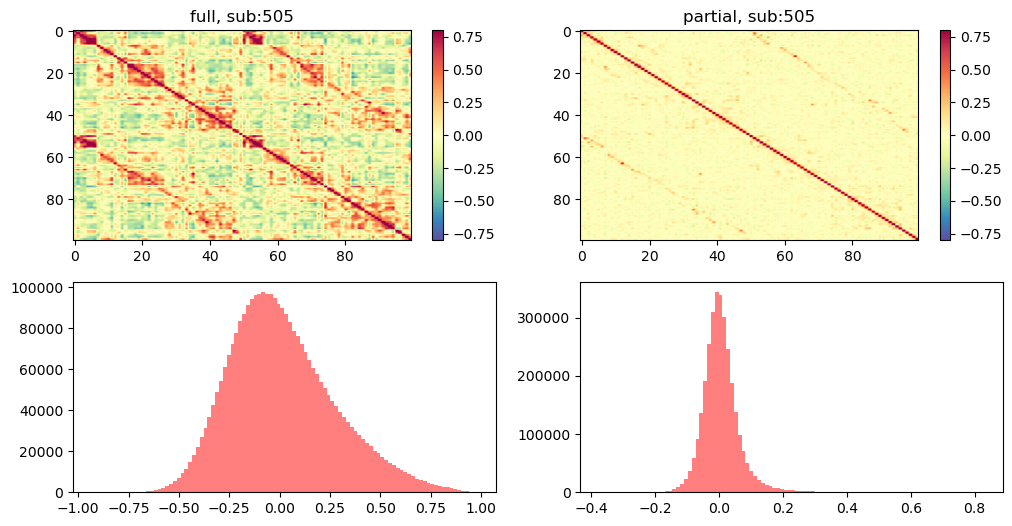

In [29]:
from utils import * #make_netmat

# make into visualization to check all is good
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()
ii=0 

rand_ii = int(np.random.uniform(0,N))
full_mat = make_netmat(te_netmat_np_full[rand_ii])
partial_mat = make_netmat(te_netmat_np_partial[rand_ii])

img0 = axes[ii].imshow(full_mat, aspect="auto", vmin=-0.8, vmax=0.8, cmap="Spectral_r")
axes[ii].set_title(f"full, sub:{rand_ii}")
plt.colorbar(img0, ax=axes[ii])

img1 = axes[ii+1].imshow(partial_mat, aspect="auto", vmin=-0.8, vmax=0.8, cmap="Spectral_r")
axes[ii+1].set_title(f"partial, sub:{rand_ii}")
plt.colorbar(img1, ax=axes[ii+1])

axes[ii+2].hist(te_netmat_np_full.flatten(), bins=100, color='red', label="target", alpha=0.5)
axes[ii+3].hist(te_netmat_np_partial.flatten(), bins=100, color='red', label="target", alpha=0.5)

img_extension="png"
filename = f'/full_partial_examples_and_histogram_comparisons.{img_extension}'
directory=f"{data_root_path}/NeuroTranslate/surf2netmat/images/ABCD/"
print(f'Saving to path:{directory}')
# Save the figure
plt.savefig(directory + filename, format=img_extension)
plt.show()
